In [247]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

import os
print(os.getcwd())

C:\Users\athethi\Jupiter NoteBook - Data Analyst\CapStone_Project


In [249]:
filename1 = "Proposals_final.csv"
df1 = pd.read_csv(filename1) 
df1.head()

,Proposal Department,Original Sponsor Type,Proposed Start Date,Proposed End Date,Current Status,Submitted Date,Awarded Date,Cost,Price,Recovery,Keyword
0,Earth Science and Engineering,UK Charity Peer/Open,01/02/2026 00:00,31/07/2028 00:00,Submitted,12/05/2025 00:00,NaN,"£1,094,311.03","£495,772.88",45.30%,"ENGINEERING: Energy generation, conversion and..."
1,Chemical Engineering and Chemical Technology,Other Sources,01/10/2025 00:00,30/09/2028 00:00,Submitted,12/05/2025 00:00,NaN,"£886,025.89","£698,789.28",78.87%,CHEM SCI: Electrochemistry
2,Materials,Other Sources,01/10/2025 00:00,30/09/2028 00:00,Submitted,12/05/2025 00:00,NaN,"£1,014,351.26","£808,858.72",79.74%,CHEM SCI: Electrochemistry
3,Materials,Research Councils,01/10/2025 00:00,28/02/2026 00:00,Submitted,12/05/2025 00:00,NaN,"£74,541.01","£59,632.81",80.00%,ENGINEERING: Functional materials
4,Materials,Research Councils,01/10/2025 00:00,28/02/2026 00:00,Submitted,12/05/2025 00:00,NaN,"£57,733.86","£46,187.08",80.00%,BIOMED AND CLINICAL SCI: Nanomedicine


In [464]:
df1.info()
df_plot.info()
df_plot['Cost'] = df1['Cost']
df_plot['Price'] = df1['Price']
df_plot['Recovery'] = df1['Recovery']
df_plot.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8783 entries, 0 to 8782
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Proposal Department    8783 non-null   object
 1   Original Sponsor Type  8783 non-null   object
 2   Proposed Start Date    8783 non-null   object
 3   Proposed End Date      8783 non-null   object
 4   Current Status         8783 non-null   object
 5   Submitted Date         8783 non-null   object
 6   Awarded Date           2741 non-null   object
 7   Cost                   8783 non-null   object
 8   Price                  8783 non-null   object
 9   Recovery               8736 non-null   object
 10  Keyword                8783 non-null   object
dtypes: object(11)
memory usage: 754.9+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 2741 entries, 41 to 8780
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------              

,Proposal Department,Original Sponsor Type,Proposed Start Date,Proposed End Date,Current Status,Submitted Date,Awarded Date,Cost,Price,Recovery,Keyword,Awarded,Month,Year,Project_Keyword,Sponsor_Type
41,Computing,Research Councils,2025-04-01,2026-03-31,Awarded,2025-04-29,2025-04-22,£0.00,£0.00,NaN,INFO AND COMPUTING SCI: Cyberphysical systems ...,True,4,2025,INFO AND COMPUTING SCI,Research Councils
42,Computing,Research Councils,2025-04-01,2026-03-31,Awarded,2025-04-29,2025-04-22,"£1,571,606.83","£1,245,696.12",79.26%,INFO AND COMPUTING SCI: Cyberphysical systems ...,True,4,2025,INFO AND COMPUTING SCI,Research Councils
63,Civil and Environmental Engineering,"UK industry, commerce & public corporations",2025-04-01,2025-12-31,Awarded,2025-04-15,2025-03-26,"£129,411.62","£129,411.62",100.00%,EARTH SCI: Earth and space science informatics,True,3,2025,EARTH SCI,Industry
68,Computing,"UK industry, commerce & public corporations",2025-03-01,2029-02-28,Awarded,2025-04-15,2025-03-12,"£339,249.73","£358,436.51",105.66%,INFO AND COMPUTING SCI: Artificial life and co...,True,3,2025,INFO AND COMPUTING SCI,Industry
70,Earth Science and Engineering,Research Councils,2025-05-01,2028-04-30,Awarded,2025-04-14,2025-04-14,"£697,627.41","£567,684.10",81.37%,EARTH SCI: Planetary geology,True,4,2025,EARTH SCI,Research Councils


In [63]:
df1['Proposed Start Date'] = pd.to_datetime(df1['Proposed Start Date'], errors = 'coerce', dayfirst = True )
df1['Proposed End Date'] = pd.to_datetime(df1['Proposed End Date'], errors = 'coerce', dayfirst = True)
df1['Submitted Date'] = pd.to_datetime(df1['Submitted Date'], errors = 'coerce', dayfirst = True)
df1['Awarded Date'] = pd.to_datetime(df1['Awarded Date'], errors='coerce', dayfirst=True)

In [65]:
print(df1['Proposed Start Date'].dtype)
print(df1['Proposed End Date'].dtype)
print(df1['Submitted Date'].dtype)
print(df1['Awarded Date'].dtype)

datetime64[ns]
datetime64[ns]
datetime64[ns]
datetime64[ns]


In [67]:

df1.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8783 entries, 0 to 8782
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Proposal Department    8783 non-null   object        
 1   Original Sponsor Type  8783 non-null   object        
 2   Proposed Start Date    8783 non-null   datetime64[ns]
 3   Proposed End Date      8783 non-null   datetime64[ns]
 4   Current Status         8783 non-null   object        
 5   Submitted Date         8783 non-null   datetime64[ns]
 6   Awarded Date           2741 non-null   datetime64[ns]
 7   Cost                   8783 non-null   object        
 8   Price                  8783 non-null   object        
 9   Recovery               8736 non-null   object        
 10  Keyword                8783 non-null   object        
dtypes: datetime64[ns](4), object(7)
memory usage: 754.9+ KB


In [381]:
df_plot['Original Sponsor Type'].unique()

Replacement_dict = {'Research Councils' : 'Research Councils' ,
                     'UK industry, commerce & public corporations' : 'Industry',
                       'UK central government bodies/local authorities, health' : 'Government',
                       "UK Health & Hosp Auth's, NHS/General Med or DoH" : 'Health',
                       'European Commission' : 'EU',
                        'UK Charity Not Peer/Not Open' : 'Charity Not Open',
                       'Other Sources' : 'Other',
                        'EU Industry, Commerce & Public Corporations' : 'Industry',
                        'Other Overseas' : 'Other',
                        'Other Overseas Industry, Commerce & Public Corporations' : 'Industry',
                         'UK Charity Peer/Open' : 'Charity Open', 
                        'Overseas Charity Not Peer/Not Open' : 'Charity Not Open',
                        'EU Other' : 'Other',
                        'Overseas Charity Peer/Open' : 'Charity Open', 
                        'EU Charity Peer/Open' : 'Charity Open',
                       'Default Sponsor Type' : 'Default', 
                        'EU Charity Not Peer/Not Open' : 'Charity Not Open',
                         'EU Government Bodies' : 'Government'}

df_plot['Sponsor_Type'] = df_plot['Original Sponsor Type'].replace(Replacement_dict)
                        
df_plot['Sponsor_Type'].unique()

array(['Research Councils', 'Industry', 'Government', 'Health', 'EU',
       'Charity Not Open', 'Other', 'Charity Open', 'Default'],
      dtype=object)

In [45]:
df_plot = df1.dropna(subset=['Awarded Date', 'Keyword', 'Current Status', 'Proposal Department'])

In [321]:
df_plot.info()
df_plot.head()

<class 'pandas.core.frame.DataFrame'>
Index: 2741 entries, 41 to 8780
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Proposal Department    2741 non-null   object        
 1   Original Sponsor Type  2741 non-null   object        
 2   Proposed Start Date    2741 non-null   datetime64[ns]
 3   Proposed End Date      2741 non-null   datetime64[ns]
 4   Current Status         2741 non-null   object        
 5   Submitted Date         2741 non-null   datetime64[ns]
 6   Awarded Date           2741 non-null   datetime64[ns]
 7   Cost                   0 non-null      float64       
 8   Price                  0 non-null      float64       
 9   Recovery               16 non-null     float64       
 10  Keyword                2741 non-null   object        
 11  Awarded                2741 non-null   int32         
 12  Month                  2741 non-null   int32         
 13  Year   

,Proposal Department,Original Sponsor Type,Proposed Start Date,Proposed End Date,Current Status,Submitted Date,Awarded Date,Cost,Price,Recovery,Keyword,Awarded,Month,Year,Project_Keyword
41,Computing,Research Councils,2025-04-01,2026-03-31,Awarded,2025-04-29,2025-04-22,NaN,NaN,NaN,INFO AND COMPUTING SCI: Cyberphysical systems ...,1,4,2025,INFO AND COMPUTING SCI
42,Computing,Research Councils,2025-04-01,2026-03-31,Awarded,2025-04-29,2025-04-22,NaN,NaN,NaN,INFO AND COMPUTING SCI: Cyberphysical systems ...,1,4,2025,INFO AND COMPUTING SCI
63,Civil and Environmental Engineering,"UK industry, commerce & public corporations",2025-04-01,2025-12-31,Awarded,2025-04-15,2025-03-26,NaN,NaN,NaN,EARTH SCI: Earth and space science informatics,1,3,2025,EARTH SCI
68,Computing,"UK industry, commerce & public corporations",2025-03-01,2029-02-28,Awarded,2025-04-15,2025-03-12,NaN,NaN,NaN,INFO AND COMPUTING SCI: Artificial life and co...,1,3,2025,INFO AND COMPUTING SCI
70,Earth Science and Engineering,Research Councils,2025-05-01,2028-04-30,Awarded,2025-04-14,2025-04-14,NaN,NaN,NaN,EARTH SCI: Planetary geology,1,4,2025,EARTH SCI


<Axes: xlabel='Awarded Date', ylabel='Current Status'>

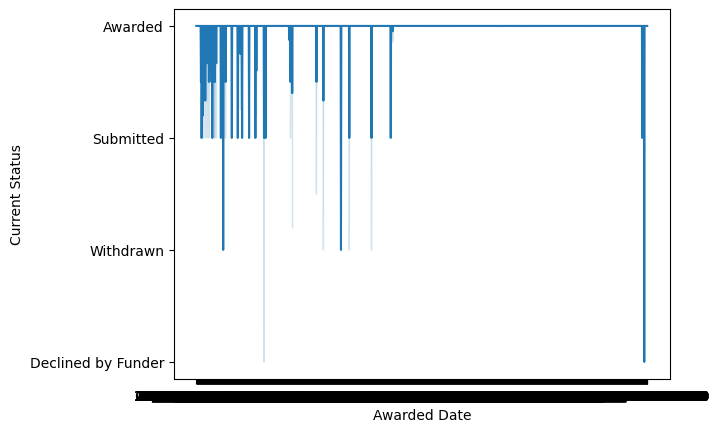

In [13]:
sns.lineplot(df_plot, x = 'Awarded Date', y = 'Current Status')

In [15]:

Awarded_monthly_counts = df_plot.groupby('Month',).size().reset_index(name='Awarded')


In [73]:
print(Awarded_monthly_counts.head())

       Month  Awarded
0 2008-12-01        3
1 2013-08-01        1
2 2014-02-01        1
3 2014-12-01        1
4 2015-01-01        1


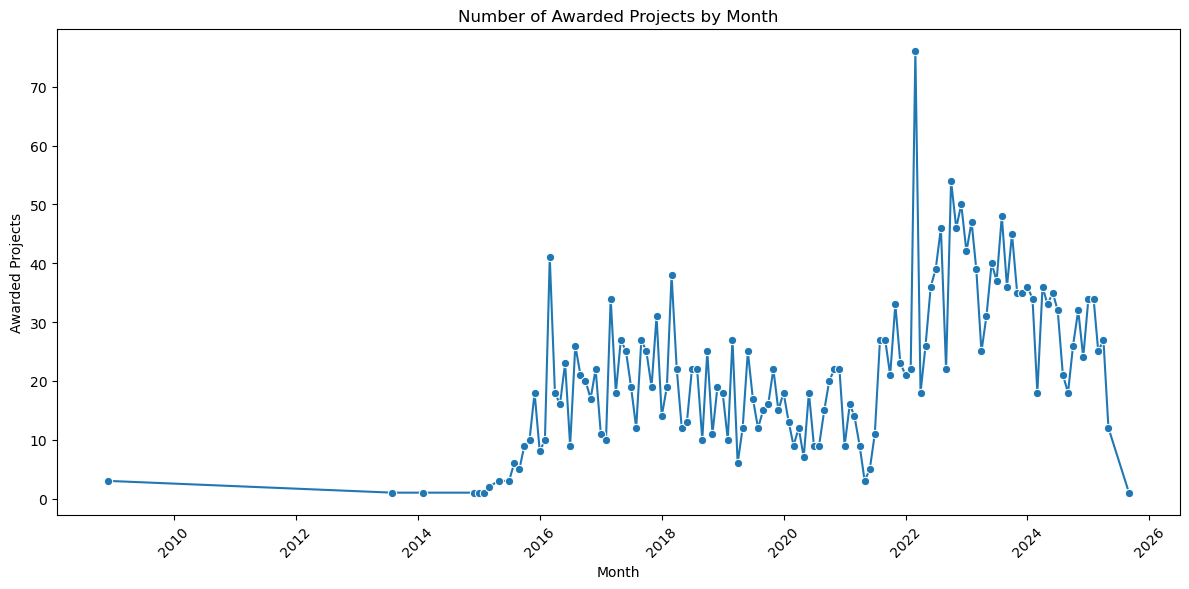

In [75]:

plt.figure(figsize=(12, 6))
sns.lineplot(data=Awarded_monthly_counts, x='Month', y='Awarded', marker='o')
plt.title('Number of Awarded Projects by Month')
plt.ylabel('Awarded Projects')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [77]:
import re

# Combine all text in the column into a single string
all_text = ' '.join(df_plot['Keyword'].dropna().astype(str))

# Use regex to extract words (removes punctuation, etc.)
words = re.findall(r'\b\w+\b', all_text.lower())  # Convert to lowercase for consistency

# Get unique words
unique_words = set(words)

# Convert to sorted list if needed
unique_words = sorted(unique_words)

# Display first 20 for example
print(unique_words[:20])



['access', 'acids', 'acoustics', 'activity', 'acute', 'adaptation', 'adaptive', 'additive', 'aerodynamics', 'aerosols', 'aerospace', 'aerothermodynamics', 'agents', 'agri', 'agricultural', 'agriculture', 'aided', 'air', 'aircraft', 'algebraic']


In [79]:


def Keyword_before_colon(title):
    match = re.search(r'^([A-Z\s]+):', str(title))
    return match.group(1).strip() if match else None

# Apply function to the column
df_plot['Project_Keyword'] = df_plot['Keyword'].apply(Keyword_before_colon)

print(df_plot[['Keyword', 'Project_Keyword']].head())




                                              Keyword         Project_Keyword
41  INFO AND COMPUTING SCI: Cyberphysical systems ...  INFO AND COMPUTING SCI
42  INFO AND COMPUTING SCI: Cyberphysical systems ...  INFO AND COMPUTING SCI
63     EARTH SCI: Earth and space science informatics               EARTH SCI
68  INFO AND COMPUTING SCI: Artificial life and co...  INFO AND COMPUTING SCI
70                       EARTH SCI: Planetary geology               EARTH SCI


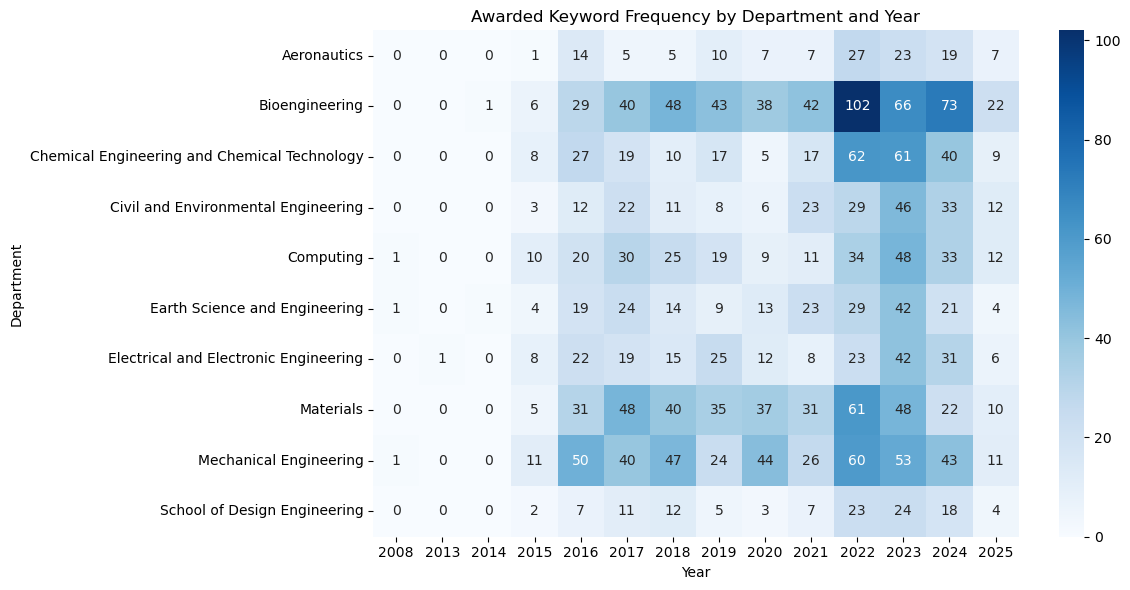

In [448]:
df_plot['Year'] = df_plot['Awarded Date'].dt.year
df_awarded = df_plot[df_plot['Current Status'] == 'Awarded']

pivot_table = df_awarded.groupby(['Proposal Department', 'Year'])['Project_Keyword'].count().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, cmap='Blues', annot=True, fmt='d')
plt.title("Awarded Keyword Frequency by Department and Year")
plt.xlabel("Year")
plt.ylabel("Department")
plt.tight_layout()
plt.show()

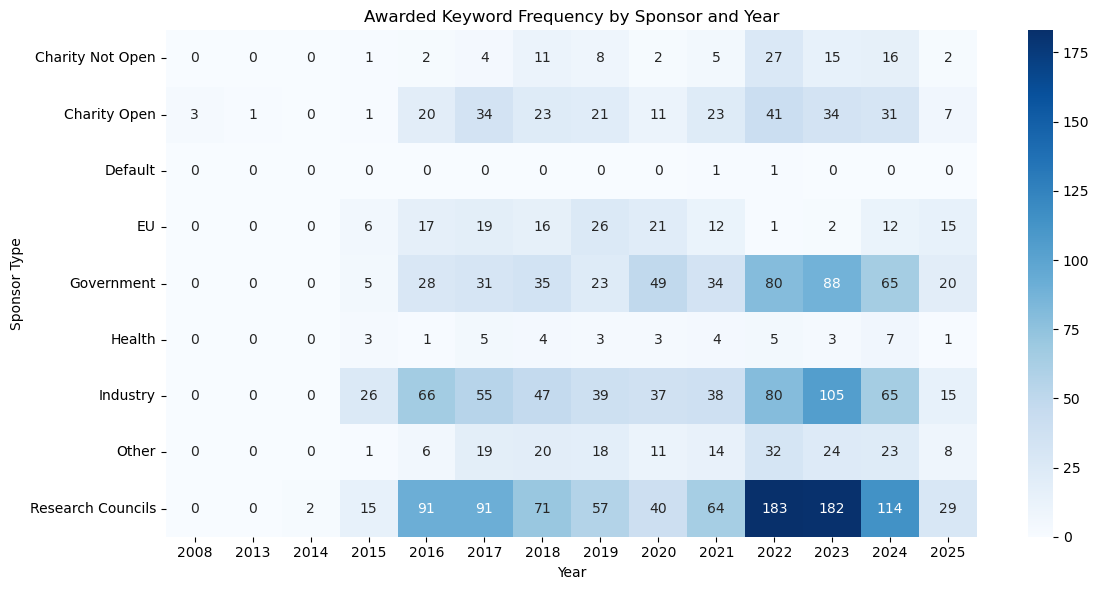

In [450]:
df_awarded = df_plot[df_plot['Current Status'] == 'Awarded']

pivot_table = df_awarded.groupby(['Sponsor_Type', 'Year'])['Project_Keyword'].count().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, cmap='Blues', annot=True, fmt='d')
plt.title("Awarded Keyword Frequency by Sponsor and Year")
plt.xlabel("Year")
plt.ylabel("Sponsor Type")
plt.tight_layout()
plt.show()

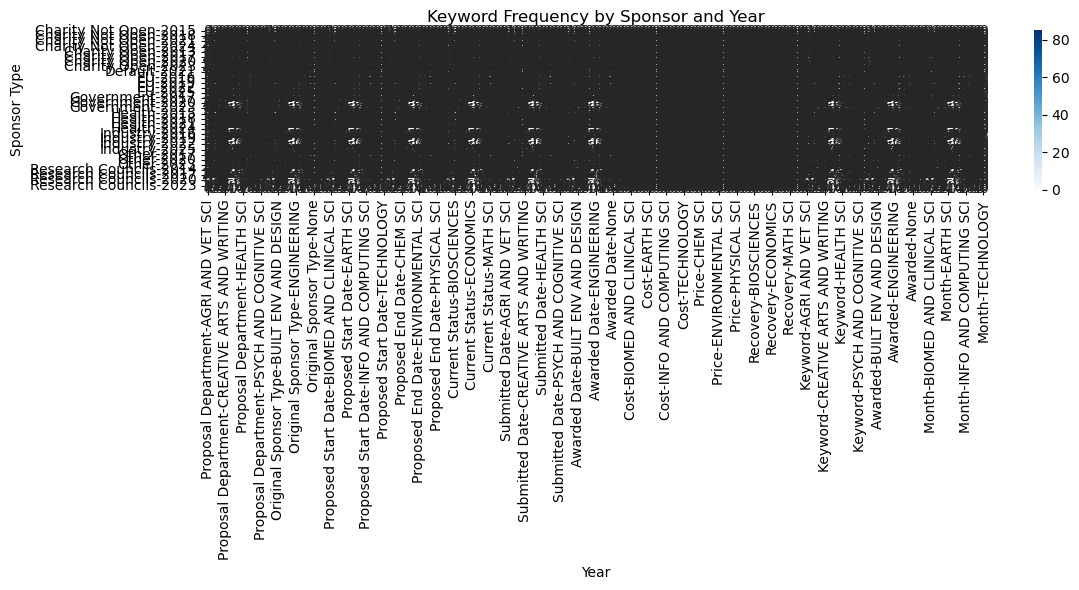

In [405]:

df_awarded = df_plot[df_plot['Current Status'] == 'Awarded']
pivot_table = df_awarded.groupby(['Sponsor_Type', 'Year', 'Project_Keyword']).count().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, cmap='Blues', annot=True, fmt='d')
plt.title("Keyword Frequency by Sponsor and Year")
plt.xlabel("Year")
plt.ylabel("Sponsor Type")
plt.tight_layout()
plt.show()




In [99]:
df_awarded = df_plot[df_plot['Current Status'] == 'Awarded']

df_awarded.loc[:, 'Year'] = pd.to_datetime(df_awarded['Awarded Date'], dayfirst=True, errors='coerce').dt.year

latest_year = df_awarded['Year'].max()
last_3_years = [latest_year - i for i in range(3)]
df_recent = df_plot[df_plot['Year'].isin(last_3_years)]

total_awarded = df_recent.groupby(['Proposal Department', 'Year']).size().reset_index(name='Total_Awarded')

keyword_awarded = df_recent.groupby(['Proposal Department', 'Year', 'Project_Keyword']).size().reset_index(name='Keyword_Awarded')

merged = keyword_awarded.merge(total_awarded, on=['Proposal Department', 'Year'])
merged['Keyword_Share'] = (merged['Keyword_Awarded'] / merged['Total_Awarded']) * 100

avg_keyword_share = merged.groupby(['Proposal Department', 'Project_Keyword'])['Keyword_Share'].mean().reset_index(name='Avg_Keyword_Share_3yr')



In [83]:
print(avg_keyword_share.head(10))

             Proposal Department            Project_Keyword  \
0   School of Design Engineering    BIOMED AND CLINICAL SCI   
1   School of Design Engineering       BUILT ENV AND DESIGN   
2   School of Design Engineering                   CHEM SCI   
3   School of Design Engineering  CREATIVE ARTS AND WRITING   
4   School of Design Engineering                  EARTH SCI   
5   School of Design Engineering                  ECONOMICS   
6   School of Design Engineering                ENGINEERING   
7   School of Design Engineering                 HEALTH SCI   
8   School of Design Engineering     INFO AND COMPUTING SCI   
9   School of Design Engineering    PSYCH AND COGNITIVE SCI   

   Avg_Keyword_Share_3yr  
0              11.740891  
1              10.526316  
2              14.285714  
3              10.526316  
4               3.846154  
5               7.692308  
6              60.921535  
7               5.263158  
8              12.116831  
9               5.263158  


In [85]:

print(avg_keyword_share[avg_keyword_share['Proposal Department'] == 'Computing'])


   Proposal Department          Project_Keyword  Avg_Keyword_Share_3yr
44           Computing  BIOMED AND CLINICAL SCI               8.635531
45           Computing                 CHEM SCI               5.599817
46           Computing                ECONOMICS               2.083333
47           Computing              ENGINEERING               5.327381
48           Computing               HEALTH SCI               4.940476
49           Computing   INFO AND COMPUTING SCI              75.625763
50           Computing                 MATH SCI               3.898810


In [103]:
df_plot.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2741 entries, 41 to 8780
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Proposal Department    2741 non-null   object        
 1   Original Sponsor Type  2741 non-null   object        
 2   Proposed Start Date    2741 non-null   datetime64[ns]
 3   Proposed End Date      2741 non-null   datetime64[ns]
 4   Current Status         2741 non-null   object        
 5   Submitted Date         2741 non-null   datetime64[ns]
 6   Awarded Date           2741 non-null   datetime64[ns]
 7   Cost                   2741 non-null   object        
 8   Price                  2741 non-null   object        
 9   Recovery               2719 non-null   object        
 10  Keyword                2741 non-null   object        
 11  Awarded                2741 non-null   bool          
 12  Month                  2741 non-null   datetime64[ns]
 13  Year   

In [141]:
df_plot['Awarded_Flag'] = df_plot['Current Status'].apply(lambda x: 'Yes' if x.lower() == 'awarded' else 'No')
df_plot = df_plot.drop('Awarded_Flag', axis=1)

df_plot.info()
print(df_plot['Awarded'].unique())
print(df_plot['Current Status'].unique())
df_plot.head()

<class 'pandas.core.frame.DataFrame'>
Index: 2741 entries, 41 to 8780
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Proposal Department    2741 non-null   object        
 1   Original Sponsor Type  2741 non-null   object        
 2   Proposed Start Date    2741 non-null   datetime64[ns]
 3   Proposed End Date      2741 non-null   datetime64[ns]
 4   Current Status         2741 non-null   object        
 5   Submitted Date         2741 non-null   datetime64[ns]
 6   Awarded Date           2741 non-null   datetime64[ns]
 7   Cost                   2741 non-null   object        
 8   Price                  2741 non-null   object        
 9   Recovery               2719 non-null   object        
 10  Keyword                2741 non-null   object        
 11  Awarded                2741 non-null   bool          
 12  Month                  2741 non-null   int32         
 13  Year   

,Proposal Department,Original Sponsor Type,Proposed Start Date,Proposed End Date,Current Status,Submitted Date,Awarded Date,Cost,Price,Recovery,Keyword,Awarded,Month,Year,Project_Keyword
41,Computing,Research Councils,2025-04-01,2026-03-31,Awarded,2025-04-29,2025-04-22,£0.00,£0.00,NaN,INFO AND COMPUTING SCI: Cyberphysical systems ...,True,4,2025,INFO AND COMPUTING SCI
42,Computing,Research Councils,2025-04-01,2026-03-31,Awarded,2025-04-29,2025-04-22,"£1,571,606.83","£1,245,696.12",79.26%,INFO AND COMPUTING SCI: Cyberphysical systems ...,True,4,2025,INFO AND COMPUTING SCI
63,Civil and Environmental Engineering,"UK industry, commerce & public corporations",2025-04-01,2025-12-31,Awarded,2025-04-15,2025-03-26,"£129,411.62","£129,411.62",100.00%,EARTH SCI: Earth and space science informatics,True,3,2025,EARTH SCI
68,Computing,"UK industry, commerce & public corporations",2025-03-01,2029-02-28,Awarded,2025-04-15,2025-03-12,"£339,249.73","£358,436.51",105.66%,INFO AND COMPUTING SCI: Artificial life and co...,True,3,2025,INFO AND COMPUTING SCI
70,Earth Science and Engineering,Research Councils,2025-05-01,2028-04-30,Awarded,2025-04-14,2025-04-14,"£697,627.41","£567,684.10",81.37%,EARTH SCI: Planetary geology,True,4,2025,EARTH SCI


In [462]:

# Random Forest

# Step 1: Convert numeric columns stored as objects
for col in ['Cost', 'Price', 'Recovery']:
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')  # converts invalid strings to NaN


# Step 2: Drop date/time and irrelevant columns
df = df_plot.drop([
    'Proposed Start Date',
    'Proposed End Date',
    'Submitted Date',
    'Awarded Date',
    'Keyword',
    'Recovery'
], axis=1)

# Step 3: Create target variable
y = df['Awarded'].astype(int)  # Convert boolean to 0/1
X = df.drop('Awarded', axis=1)

# Step 4: One-hot encode categorical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
X_encoded = pd.get_dummies(X, columns=categorical_cols)

# Drop rows with any NaNs or infinite values
X_encoded = X_encoded.fillna(0)
y = y.loc[X_encoded.index]  # Keep target aligned


X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, random_state=22)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

print(f"Shape of data after cleaning: {X_encoded.shape}")
print(y.value_counts())



              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00       668

    accuracy                           1.00       686
   macro avg       1.00      1.00      1.00       686
weighted avg       1.00      1.00      1.00       686

Shape of data after cleaning: (2741, 62)
Awarded
1    2677
0      64
Name: count, dtype: int64


In [466]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
import warnings
warnings.filterwarnings('ignore')

# Decision Tree

# Step 1: Convert numeric columns stored as objects
for col in ['Cost', 'Price', 'Recovery']:
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')  # converts invalid strings to NaN

# Step 2: Drop date/time and irrelevant columns
df = df_plot.drop([
    'Proposed Start Date',
    'Proposed End Date',
    'Submitted Date',
    'Awarded Date',
    'Keyword',
    'Recovery'
], axis=1)

# Step 3: Create target variable
y = df['Awarded'].astype(int)  # Convert boolean to 0/1
X = df.drop('Awarded', axis=1)

# Step 4: One-hot encode categorical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
X_encoded = pd.get_dummies(X, columns=categorical_cols)

# Drop rows with any NaNs or infinite values

X_encoded = X_encoded.fillna(0)
y = y.loc[X_encoded.index]  # Keep target aligned


X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, random_state=22)

Dtree = DecisionTreeClassifier()
Dtree.fit(X_train, y_train)

y_pred = Dtree.predict(X_test)

train_accuracy = Dtree.score(X_train, y_train)
test_accuracy = Dtree.score(X_test, y_test)

print(f'Train accuracy: {train_accuracy: .4f}')
print(f'Test accuracy: {test_accuracy: .4f}')



Train accuracy:  1.0000
Test accuracy:  1.0000


In [307]:


# Step 1: Prepare source data
df_plot['Awarded'] = df_plot['Awarded'].astype(int)

# Step 2: Compute global (overall) success rate
overall_rate = df_plot['Awarded'].mean()

# Step 3: Compute group success rate + smoothing
grouped = df_plot.groupby(['Proposal Department', 'Project_Keyword'])['Awarded'].agg(['sum', 'count'])
grouped = grouped.rename(columns={'sum': 'awarded', 'count': 'total'})

# Bayesian smoothing: blend with global rate
k = 2  # smoothing factor (higher = more smoothing)
grouped['success_rate'] = (grouped['awarded'] + k * overall_rate) / (grouped['total'] + k)

# Reset index for merging
success_rate_dept_kw = grouped[['success_rate']].reset_index()

# Step 4: Department-only fallback
dept_fallback = (
    df_plot.groupby('Proposal Department')['Awarded']
    .agg(['sum', 'count'])
    .assign(success_rate=lambda x: (x['sum'] + k * overall_rate) / (x['count'] + k))
    .reset_index()[['Proposal Department', 'success_rate']]
    .rename(columns={'success_rate': 'dept_rate'})
)

# Step 5: Keyword-only fallback
kw_fallback = (
    df_plot.groupby('Project_Keyword')['Awarded']
    .agg(['sum', 'count'])
    .assign(success_rate=lambda x: (x['sum'] + k * overall_rate) / (x['count'] + k))
    .reset_index()[['Project_Keyword', 'success_rate']]
    .rename(columns={'success_rate': 'kw_rate'})
)

# ================================
# Step 6: Apply to new dataset
# ================================

# Merge the full-rate (dept + keyword)
df_forecast = df2_renamed.merge(success_rate_dept_kw, on=['Proposal Department', 'Project_Keyword'], how='left')

# Merge fallbacks
df_forecast = df_forecast.merge(dept_fallback, on='Proposal Department', how='left')
df_forecast = df_forecast.merge(kw_fallback, on='Project_Keyword', how='left')

# Fill missing with fallbacks
df_forecast['Forecasted_Success_Rate'] = df_forecast['success_rate']
df_forecast['Forecasted_Success_Rate'] = df_forecast['Forecasted_Success_Rate'].fillna(df_forecast['dept_rate'])
df_forecast['Forecasted_Success_Rate'] = df_forecast['Forecasted_Success_Rate'].fillna(df_forecast['kw_rate'])
df_forecast['Forecasted_Success_Rate'] = df_forecast['Forecasted_Success_Rate'].fillna(overall_rate)





In [309]:
# Check how many rows didn't get a match on the full department+keyword merge
missing_main_match = df_forecast['success_rate'].isna().sum()
print(f"Rows with no (dept + keyword) match: {missing_main_match}")

# Check how many still missing after department fallback
missing_dept = df_forecast['Forecasted_Success_Rate'].isna().sum()
print(f"Rows with no (dept or keyword) fallback: {missing_dept}")

# Final check: should be zero after overall_rate fallback
missing_final = df_forecast['Forecasted_Success_Rate'].isna().sum()
print(f"Rows STILL missing after all fallbacks (should be 0): {missing_final}")

Rows with no (dept + keyword) match: 9354
Rows with no (dept or keyword) fallback: 0
Rows STILL missing after all fallbacks (should be 0): 0


In [311]:
print("Original new dataset rows:", len(df2_renamed))
print("After merge (df_forecast) rows:", len(df_forecast))

Original new dataset rows: 9354
After merge (df_forecast) rows: 9354


In [313]:
df_forecast[['Proposal Department', 'Project_Keyword', 'success_rate', 'dept_rate', 'kw_rate', 'Forecasted_Success_Rate']].sample(10)

,Proposal Department,Project_Keyword,success_rate,dept_rate,kw_rate,Forecasted_Success_Rate
4680,Mechanical Engineering,Evaluation; Mech Eng: Applied Mechanics; Non-D...,NaN,0.995056,NaN,0.995056
8470,Electrical and Electronic Engineering,Approach; Control; Electrical Engineering: Con...,NaN,0.990525,NaN,0.990525
6524,Earth Science and Engineering,nan,NaN,0.990160,NaN,0.990160
197,Chemical Engineering and Chemical Technology,CHEM SCI: Solid state chemistry; Chemical Engi...,NaN,0.982104,NaN,0.982104
8571,Mechanical Engineering,nan,NaN,0.995056,NaN,0.995056
5546,Mechanical Engineering,Chemical Engineering: Energy/Sustainability; C...,NaN,0.995056,NaN,0.995056
7783,Electrical and Electronic Engineering,BIOSCIENCES: Signal transduction; Digital; Dig...,NaN,0.990525,NaN,0.990525
7574,Mechanical Engineering,Bioenergy; Biofuel; Biomass; Combustion; ENGIN...,NaN,0.995056,NaN,0.995056
2455,Aeronautics,Impact; Life Sciences: Molecular mechanisms of...,NaN,0.961767,NaN,0.961767
2996,Chemical Engineering and Chemical Technology,nan,NaN,0.982104,NaN,0.982104


In [315]:
print(df_forecast['Forecasted_Success_Rate'].describe())

count    9354.000000
mean        0.978697
std         0.022216
min         0.911689
25%         0.973295
50%         0.988145
75%         0.990160
max         0.995056
Name: Forecasted_Success_Rate, dtype: float64


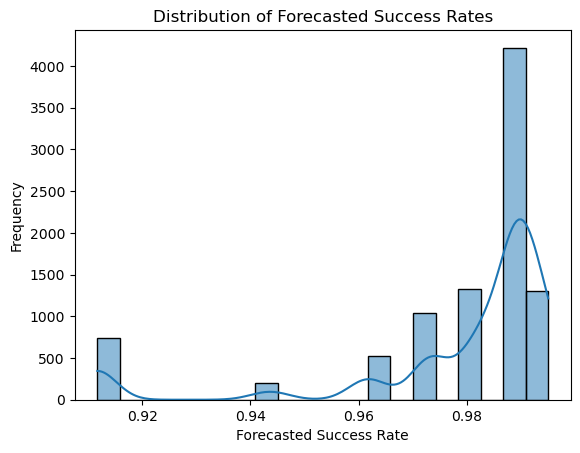

In [287]:
sns.histplot(df_forecast['Forecasted_Success_Rate'], bins=20, kde=True)
plt.title("Distribution of Forecasted Success Rates")
plt.xlabel("Forecasted Success Rate")
plt.ylabel("Frequency")
plt.show()

In [415]:

filename2 = "Running_Projects_final.csv"
df2 = pd.read_csv(filename2, encoding='ISO-8859-1')
df2.head()
df2.info()
print(df2.columns.tolist())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9354 entries, 0 to 9353
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Project Number             9354 non-null   object
 1   Project Keywords           6994 non-null   object
 2   Project Organisation       9354 non-null   object
 3   Project Department         9354 non-null   object
 4   Actual Project Start Date  9354 non-null   object
 5   Actual Project End Date    9354 non-null   object
 6   Project Creation Date      9354 non-null   object
 7   GMS Funder Type            9354 non-null   object
 8   Sum of Budget              9354 non-null   object
 9   Expenditure YTD            2299 non-null   object
 10  Expenditure 23/24          2167 non-null   object
 11  Expenditure 22/23          2071 non-null   object
 12  Expenditure 21/22          2155 non-null   object
 13  Sum of Expenditure         9354 non-null   object
dtypes: objec

In [261]:
df2_renamed = df2.rename(columns={
    'Project Department': 'Proposal Department',
    'Project Keywords': 'Project_Keyword'
})

In [265]:
df2_renamed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9354 entries, 0 to 9353
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Project Number             9354 non-null   object
 1   Project_Keyword            6994 non-null   object
 2   Project Organisation       9354 non-null   object
 3   Proposal Department        9354 non-null   object
 4   Actual Project Start Date  9354 non-null   object
 5   Actual Project End Date    9354 non-null   object
 6   Project Creation Date      9354 non-null   object
 7   GMS Funder Type            9354 non-null   object
 8   Sum of Budget              9354 non-null   object
 9   Expenditure YTD            2299 non-null   object
 10  Expenditure 23/24          2167 non-null   object
 11  Expenditure 22/23          2071 non-null   object
 12  Expenditure 21/22          2155 non-null   object
 13  Sum of Expenditure         9354 non-null   object
dtypes: objec

In [281]:
df_plot['Proposal Department'] = df_plot['Proposal Department'].astype(str).str.strip()
df_plot['Project_Keyword'] = df_plot['Project_Keyword'].astype(str).str.strip()

df2_renamed['Proposal Department'] = df2_renamed['Proposal Department'].astype(str).str.strip()
df2_renamed['Project_Keyword'] = df2_renamed['Project_Keyword'].astype(str).str.strip()

In [279]:
df_plot.info()
df2_renamed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2741 entries, 41 to 8780
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Proposal Department    2741 non-null   object        
 1   Original Sponsor Type  2741 non-null   object        
 2   Proposed Start Date    2741 non-null   datetime64[ns]
 3   Proposed End Date      2741 non-null   datetime64[ns]
 4   Current Status         2741 non-null   object        
 5   Submitted Date         2741 non-null   datetime64[ns]
 6   Awarded Date           2741 non-null   datetime64[ns]
 7   Cost                   0 non-null      float64       
 8   Price                  0 non-null      float64       
 9   Recovery               16 non-null     float64       
 10  Keyword                2741 non-null   object        
 11  Awarded                2741 non-null   bool          
 12  Month                  2741 non-null   int32         
 13  Year   

In [277]:
df2_renamed['Actual Project Start Date'] = pd.to_datetime(df2_renamed['Actual Project Start Date'], errors = 'coerce', dayfirst = True )
df2_renamed['Actual Project End Date'] = pd.to_datetime(df2_renamed['Actual Project End Date'], errors = 'coerce', dayfirst = True)